# Final Price-Level DBSCAN + HDBSCAN Notebook

Price-only clustering into exactly three meaningful national housing price levels.
UTM coordinates are only used for visualization, not for clustering.

In [1]:
%pip install -q gdown hdbscan pyproj

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
import json
import shutil
import warnings
from pathlib import Path

import gdown
import hdbscan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyproj import Transformer
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings("ignore")

In [3]:
FOLDER_URL = "https://drive.google.com/drive/folders/1RZJdNpCfbMt2SB_kfWsxQgOk5LeuV7lw"
OUTPUT_ROOT = Path("/kaggle/working")
DATA_DIR = OUTPUT_ROOT / "divar_dataset"
RESULT_DIR = OUTPUT_ROOT / "price_level_clustering_outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET_CLUSTERS = 3

DBSCAN_TUNING_SIZE = 25000
HDBSCAN_TUNING_SIZE = 30000
HDBSCAN_TRAIN_SIZE = 70000

METRIC_SAMPLE_SIZE = 10000
PLOT_SAMPLE_SIZE = 50000

DBSCAN_TARGET_MICRO_CLUSTERS = 24
DBSCAN_MIN_FINAL_SHARE = 0.20
DBSCAN_MAX_FINAL_SHARE = 0.55
DBSCAN_BALANCE_STRENGTH_GRID = [0.75, 1.25, 2.00, 3.50, 5.00, 8.00]

PRICE_LEVEL_NAMES = {
    0: "Economy",
    1: "Mid-range",
    2: "Premium"
}

PRICE_LEVEL_ORDER = ["Economy", "Mid-range", "Premium"]

PRICE_LEVEL_COLORS = {
    "Economy": "#2A9D8F",
    "Mid-range": "#E9C46A",
    "Premium": "#E76F51"
}

MODEL_COLORS = {
    "DBSCAN": "#4361EE",
    "HDBSCAN": "#7209B7"
}

NOISE_COLOR = "#ADB5BD"

In [4]:
downloaded_files = gdown.download_folder(
    url=FOLDER_URL,
    output=str(DATA_DIR),
    quiet=False,
    use_cookies=False
)

csv_files = glob.glob(str(DATA_DIR / "**" / "*.csv"), recursive=True)

if len(csv_files) == 0:
    csv_files = glob.glob(str(OUTPUT_ROOT / "**" / "*.csv"), recursive=True)

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file was found after downloading the Google Drive folder.")

DATA_PATH = max(csv_files, key=os.path.getsize)

DATA_PATH

Retrieving folder contents


Processing file 1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ Divar.csv
Processing file 1eX9an3tSypvrFn_fiPReYHTca5GpJaJG iran_city_classification.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ
From (redirected): https://drive.google.com/uc?id=1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ&confirm=t&uuid=5b6e5484-b964-4366-b3b0-f74da2b6a780
To: /kaggle/working/divar_dataset/Divar.csv
100%|██████████| 794M/794M [00:10<00:00, 78.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1eX9an3tSypvrFn_fiPReYHTca5GpJaJG
To: /kaggle/working/divar_dataset/iran_city_classification.csv
100%|██████████| 6.16k/6.16k [00:00<00:00, 13.2MB/s]
Download completed


'/kaggle/working/divar_dataset/Divar.csv'

In [5]:
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

df.shape

(1000000, 61)

In [6]:
LAT_COL = "location_latitude"
LON_COL = "location_longitude"

price_candidates = [
    "price_transformable",
    "price_value",
    "price"
]

PRICE_COL = None

for col in price_candidates:
    if col in df.columns:
        PRICE_COL = col
        break

if PRICE_COL is None:
    raise ValueError(f"No usable price column found. Tried: {price_candidates}")

required_columns = [LAT_COL, LON_COL, PRICE_COL]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

PRICE_COL

'price_value'

In [7]:
data = df[[LAT_COL, LON_COL, PRICE_COL]].copy()

data = data.rename(
    columns={
        LAT_COL: "latitude",
        LON_COL: "longitude",
        PRICE_COL: "price"
    }
)

data["latitude"] = pd.to_numeric(data["latitude"], errors="coerce")
data["longitude"] = pd.to_numeric(data["longitude"], errors="coerce")
data["price"] = pd.to_numeric(data["price"], errors="coerce")

data = data.dropna(subset=["latitude", "longitude", "price"])
data = data[(data["latitude"].between(24, 40)) & (data["longitude"].between(43, 64))]
data = data[data["price"] > 0].copy()

low, high = data["price"].quantile([0.01, 0.99])
data = data[(data["price"] >= low) & (data["price"] <= high)].copy()

data = data.reset_index(drop=True)

data["log_price"] = np.log1p(data["price"])

data.shape

(364026, 4)

In [8]:
utm_zone = int((data["longitude"].median() + 180) / 6) + 1
epsg_code = 32600 + utm_zone

transformer = Transformer.from_crs(
    "EPSG:4326",
    f"EPSG:{epsg_code}",
    always_xy=True
)

utm_x, utm_y = transformer.transform(
    data["longitude"].to_numpy(),
    data["latitude"].to_numpy()
)

data["utm_x"] = utm_x / 1000
data["utm_y"] = utm_y / 1000

epsg_code, data[["utm_x", "utm_y", "log_price"]].head()

(32639,
          utm_x        utm_y  log_price
 0   545.711558  3954.101264  22.886589
 1   481.437131  3952.065609  20.292483
 2   568.467028  3959.664108  21.678777
 3  1266.003428  4053.542497  23.287446
 4   537.973973  3592.362039  20.560747)

In [9]:
price_scaler = RobustScaler()

X_price = price_scaler.fit_transform(
    data[["log_price"]]
).astype(np.float32)

X_price.shape

(364026, 1)

In [10]:
def price_stratified_sample_indices(
    data,
    target_size,
    random_state=42,
    price_bins=80,
    density_power=0.65,
    min_per_bin=1
):
    rng = np.random.default_rng(random_state)
    n = len(data)

    if target_size >= n:
        return np.arange(n)

    sample_frame = pd.DataFrame(index=np.arange(n))

    sample_frame["price_bin"] = pd.qcut(
        data["log_price"].rank(method="first"),
        q=min(price_bins, n),
        labels=False,
        duplicates="drop"
    )

    sample_frame = sample_frame.dropna()
    grouped = sample_frame.groupby("price_bin").groups

    groups = []
    sizes = []

    for _, indices in grouped.items():
        idx = np.array(list(indices), dtype=int)

        if len(idx) > 0:
            groups.append(idx)
            sizes.append(len(idx))

    sizes = np.array(sizes, dtype=float)

    weights = np.power(sizes, density_power)
    weights = weights / weights.sum()

    allocated = np.floor(weights * target_size).astype(int)
    allocated = np.maximum(allocated, min_per_bin)
    allocated = np.minimum(allocated, sizes.astype(int))

    while allocated.sum() > target_size:
        candidates = np.where(allocated > min_per_bin)[0]

        if len(candidates) == 0:
            break

        chosen = candidates[np.argmax(allocated[candidates])]
        allocated[chosen] -= 1

    while allocated.sum() < target_size:
        remaining_capacity = sizes.astype(int) - allocated
        candidates = np.where(remaining_capacity > 0)[0]

        if len(candidates) == 0:
            break

        probabilities = weights[candidates]
        probabilities = probabilities / probabilities.sum()

        chosen = rng.choice(candidates, p=probabilities)
        allocated[chosen] += 1

    sampled_indices = []

    for idx, take in zip(groups, allocated):
        if take > 0:
            sampled_indices.extend(
                rng.choice(idx, size=int(take), replace=False).tolist()
            )

    sampled_indices = np.array(sampled_indices, dtype=int)

    if len(sampled_indices) > target_size:
        sampled_indices = rng.choice(sampled_indices, size=target_size, replace=False)

    if len(sampled_indices) < target_size:
        missing = target_size - len(sampled_indices)
        remaining = np.setdiff1d(np.arange(n), sampled_indices, assume_unique=False)

        if len(remaining) > 0:
            extra = rng.choice(
                remaining,
                size=min(missing, len(remaining)),
                replace=False
            )

            sampled_indices = np.concatenate([sampled_indices, extra])

    rng.shuffle(sampled_indices)

    return sampled_indices


def label_stratified_sample_indices(labels, target_size, random_state=42, density_power=0.50):
    rng = np.random.default_rng(random_state)
    labels = np.asarray(labels)
    n = len(labels)

    if target_size >= n:
        return np.arange(n)

    unique_labels, counts = np.unique(labels, return_counts=True)

    weights = np.power(counts.astype(float), density_power)
    weights = weights / weights.sum()

    allocated = np.floor(weights * target_size).astype(int)
    allocated = np.maximum(allocated, 1)
    allocated = np.minimum(allocated, counts)

    while allocated.sum() > target_size:
        candidates = np.where(allocated > 1)[0]

        if len(candidates) == 0:
            break

        chosen = candidates[np.argmax(allocated[candidates])]
        allocated[chosen] -= 1

    while allocated.sum() < target_size:
        remaining_capacity = counts - allocated
        candidates = np.where(remaining_capacity > 0)[0]

        if len(candidates) == 0:
            break

        probabilities = weights[candidates]
        probabilities = probabilities / probabilities.sum()

        chosen = rng.choice(candidates, p=probabilities)
        allocated[chosen] += 1

    sampled_indices = []

    for label, take in zip(unique_labels, allocated):
        label_indices = np.where(labels == label)[0]

        sampled_indices.extend(
            rng.choice(label_indices, size=int(take), replace=False).tolist()
        )

    sampled_indices = np.array(sampled_indices, dtype=int)
    rng.shuffle(sampled_indices)

    return sampled_indices


def safe_eps_candidates(k_distances, quantile_candidates):
    k_distances = np.asarray(k_distances)

    positive = k_distances[
        np.isfinite(k_distances) &
        (k_distances > 0)
    ]

    if len(positive) == 0:
        return np.array([1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2], dtype=float)

    eps_candidates = np.unique(
        np.quantile(positive, quantile_candidates)
    )

    eps_candidates = eps_candidates[
        np.isfinite(eps_candidates) &
        (eps_candidates > 0)
    ]

    if len(eps_candidates) == 0:
        eps_candidates = np.array([max(float(np.median(positive)), 1e-5)], dtype=float)

    eps_candidates = np.maximum(eps_candidates.astype(float), 1e-8)

    return eps_candidates


def evaluate_clustering(X, labels, metric_sample_size=10000, random_state=42):
    labels = np.asarray(labels)

    n_clusters = len(set(labels) - {-1})
    noise_ratio = float(np.mean(labels == -1))

    non_noise_mask = labels != -1
    non_noise_X = X[non_noise_mask]
    non_noise_labels = labels[non_noise_mask]

    if n_clusters < 2 or len(non_noise_X) < 100:
        return {
            "n_clusters": int(n_clusters),
            "noise_ratio": noise_ratio,
            "silhouette": -1.0,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
            "max_cluster_share": 1.0,
            "min_cluster_share": 0.0,
            "balance_gap": 1.0,
            "share_mse": 1.0
        }

    cluster_shares = pd.Series(non_noise_labels).value_counts(normalize=True)

    if len(non_noise_X) > metric_sample_size:
        metric_idx = label_stratified_sample_indices(
            non_noise_labels,
            target_size=metric_sample_size,
            random_state=random_state,
            density_power=0.50
        )

        X_metric = non_noise_X[metric_idx]
        labels_metric = non_noise_labels[metric_idx]
    else:
        X_metric = non_noise_X
        labels_metric = non_noise_labels

    try:
        silhouette = float(silhouette_score(X_metric, labels_metric))
    except Exception:
        silhouette = -1.0

    try:
        davies_bouldin = float(davies_bouldin_score(X_metric, labels_metric))
    except Exception:
        davies_bouldin = np.nan

    try:
        calinski_harabasz = float(calinski_harabasz_score(X_metric, labels_metric))
    except Exception:
        calinski_harabasz = np.nan

    expected_share = 1.0 / max(n_clusters, 1)
    share_values = cluster_shares.to_numpy()

    return {
        "n_clusters": int(n_clusters),
        "noise_ratio": noise_ratio,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "max_cluster_share": float(cluster_shares.max()),
        "min_cluster_share": float(cluster_shares.min()),
        "balance_gap": float(cluster_shares.max() - cluster_shares.min()),
        "share_mse": float(np.mean((share_values - expected_share) ** 2))
    }


def get_cluster_share_stats(labels):
    labels = np.asarray(labels)
    labels = labels[labels != -1]

    if len(labels) == 0:
        return {
            "max_share": 1.0,
            "min_share": 0.0,
            "balance_gap": 1.0,
            "share_mse": 1.0
        }

    shares = pd.Series(labels).value_counts(normalize=True).sort_index()
    expected_share = 1.0 / len(shares)

    return {
        "max_share": float(shares.max()),
        "min_share": float(shares.min()),
        "balance_gap": float(shares.max() - shares.min()),
        "share_mse": float(np.mean((shares.to_numpy() - expected_share) ** 2))
    }


def reorder_three_clusters_by_price(data, labels):
    labels = np.asarray(labels).astype(int)
    result = labels.copy()

    non_noise_labels = sorted(list(set(result) - {-1}))

    if len(non_noise_labels) != 3:
        raise ValueError(f"Expected exactly 3 non-noise clusters, got {len(non_noise_labels)}.")

    median_by_label = {}

    for label in non_noise_labels:
        median_by_label[label] = data.loc[result == label, "price"].median()

    ordered_labels = sorted(median_by_label, key=median_by_label.get)
    mapping = {old: new for new, old in enumerate(ordered_labels)}

    for old, new in mapping.items():
        result[labels == old] = new

    return result


def assign_nearest_price_level(X, centers):
    values = X.reshape(-1)
    distances = np.abs(values.reshape(-1, 1) - centers.reshape(1, -1))
    return np.argmin(distances, axis=1).astype(int)


def quantile_price_macro_cluster(data):
    rank_values = data["log_price"].rank(method="first")
    labels = pd.qcut(
        rank_values,
        q=3,
        labels=[0, 1, 2],
        duplicates="drop"
    ).astype(int).to_numpy()

    return labels


def build_balanced_contiguous_partitions(micro_summary, balance_strength=2.0, min_share=0.20):
    summary = micro_summary.sort_values("center_x").reset_index(drop=True).copy()

    centers = summary["center_x"].to_numpy(dtype=float)
    weights = summary["weight"].to_numpy(dtype=float)

    total_weight = weights.sum()
    normalized_weights = weights / total_weight

    n = len(summary)

    if n < 3:
        return None

    prefix_w = np.concatenate([[0.0], np.cumsum(weights)])
    prefix_x = np.concatenate([[0.0], np.cumsum(weights * centers)])
    prefix_x2 = np.concatenate([[0.0], np.cumsum(weights * centers * centers)])

    cumulative_share = np.cumsum(normalized_weights)

    if n <= 700:
        cut_candidates = np.arange(1, n)
    else:
        candidate_shares = np.linspace(0.05, 0.95, 500)
        cut_candidates = np.unique(np.searchsorted(cumulative_share, candidate_shares))
        cut_candidates = cut_candidates[(cut_candidates > 0) & (cut_candidates < n)]

    best_score = np.inf
    best_cuts = None
    best_centers = None
    best_shares = None

    for i in cut_candidates:
        for j in cut_candidates:
            if j <= i:
                continue

            group_ranges = [(0, i), (i, j), (j, n)]

            group_sse = 0.0
            group_centers = []
            group_shares = []

            valid = True

            for start, end in group_ranges:
                group_weight = prefix_w[end] - prefix_w[start]

                if group_weight <= 0:
                    valid = False
                    break

                group_sum = prefix_x[end] - prefix_x[start]
                group_sum2 = prefix_x2[end] - prefix_x2[start]
                group_center = group_sum / group_weight
                group_share = group_weight / total_weight
                group_sse += group_sum2 - 2 * group_center * group_sum + group_center * group_center * group_weight

                group_centers.append(group_center)
                group_shares.append(group_share)

            if not valid:
                continue

            group_shares = np.array(group_shares)
            target_share = 1.0 / 3.0

            balance_penalty = np.mean((group_shares - target_share) ** 2)
            min_share_penalty = np.sum(np.maximum(0.0, min_share - group_shares) ** 2)
            max_share_penalty = np.sum(np.maximum(0.0, group_shares - 0.60) ** 2)

            score = (
                group_sse / total_weight
                + balance_strength * balance_penalty
                + 12.0 * min_share_penalty
                + 6.0 * max_share_penalty
            )

            if score < best_score:
                best_score = score
                best_cuts = (i, j)
                best_centers = np.array(group_centers)
                best_shares = group_shares

    if best_cuts is None:
        return None

    i, j = best_cuts
    macro_by_row = np.zeros(n, dtype=int)
    macro_by_row[i:j] = 1
    macro_by_row[j:] = 2

    micro_to_macro = dict(zip(summary["micro_cluster"].to_numpy(), macro_by_row))

    return {
        "micro_to_macro": micro_to_macro,
        "centers": best_centers,
        "shares": best_shares,
        "score": float(best_score)
    }


def balanced_macro_cluster_from_micro(
    X,
    micro_labels,
    data,
    random_state=42,
    balance_strength=2.0,
    min_share=0.20
):
    micro_labels = np.asarray(micro_labels).astype(int)
    values = X.reshape(-1)

    micro_data = pd.DataFrame(
        {
            "x": values,
            "micro_cluster": micro_labels
        }
    )

    valid_micro = micro_data[micro_data["micro_cluster"] != -1]

    if valid_micro["micro_cluster"].nunique() < 3:
        return quantile_price_macro_cluster(data)

    micro_summary = (
        valid_micro
        .groupby("micro_cluster")
        .agg(
            center_x=("x", "mean"),
            weight=("micro_cluster", "size")
        )
        .reset_index()
    )

    partition = build_balanced_contiguous_partitions(
        micro_summary=micro_summary,
        balance_strength=balance_strength,
        min_share=min_share
    )

    if partition is None:
        return quantile_price_macro_cluster(data)

    macro_labels = np.full(
        shape=len(micro_labels),
        fill_value=-1,
        dtype=int
    )

    non_noise_mask = micro_labels != -1

    macro_labels[non_noise_mask] = pd.Series(
        micro_labels[non_noise_mask]
    ).map(partition["micro_to_macro"]).to_numpy().astype(int)

    noise_mask = micro_labels == -1

    if noise_mask.any():
        macro_labels[noise_mask] = assign_nearest_price_level(
            X[noise_mask],
            partition["centers"]
        )

    macro_labels = reorder_three_clusters_by_price(data, macro_labels)

    return macro_labels


def macro_cluster_from_micro(X, micro_labels, data, random_state=42):
    return balanced_macro_cluster_from_micro(
        X=X,
        micro_labels=micro_labels,
        data=data,
        random_state=random_state,
        balance_strength=2.0,
        min_share=0.20
    )


def make_cluster_summary(data, label_col, name_col):
    summary = (
        data
        .groupby([label_col, name_col])
        .agg(
            ads_count=("price", "count"),
            mean_price=("price", "mean"),
            median_price=("price", "median"),
            min_price=("price", "min"),
            max_price=("price", "max"),
            mean_log_price=("log_price", "mean"),
            mean_latitude=("latitude", "mean"),
            mean_longitude=("longitude", "mean"),
            mean_utm_x=("utm_x", "mean"),
            mean_utm_y=("utm_y", "mean")
        )
        .sort_index()
    )

    summary["share"] = summary["ads_count"] / len(data)
    summary["mean_price_billion"] = summary["mean_price"] / 1_000_000_000
    summary["median_price_billion"] = summary["median_price"] / 1_000_000_000
    summary["min_price_billion"] = summary["min_price"] / 1_000_000_000
    summary["max_price_billion"] = summary["max_price"] / 1_000_000_000

    return summary


def add_price_level_names(data, label_col, name_col):
    data[name_col] = data[label_col].map(PRICE_LEVEL_NAMES)
    return data


def print_final_report(dbscan_metrics, hdbscan_metrics):
    report = f"""
DBSCAN Price-Level Result
Clusters: {dbscan_metrics.get("n_clusters", 0)}
Noise Ratio: {dbscan_metrics.get("noise_ratio", np.nan):.4f}
Silhouette: {dbscan_metrics.get("silhouette", np.nan):.4f}
Davies-Bouldin: {dbscan_metrics.get("davies_bouldin", np.nan):.4f}
Calinski-Harabasz: {dbscan_metrics.get("calinski_harabasz", np.nan):.2f}
Max Cluster Share: {dbscan_metrics.get("max_cluster_share", np.nan):.4f}
Min Cluster Share: {dbscan_metrics.get("min_cluster_share", np.nan):.4f}
Balance Gap: {dbscan_metrics.get("balance_gap", np.nan):.4f}

HDBSCAN Price-Level Result
Clusters: {hdbscan_metrics.get("n_clusters", 0)}
Noise Ratio: {hdbscan_metrics.get("noise_ratio", np.nan):.4f}
Silhouette: {hdbscan_metrics.get("silhouette", np.nan):.4f}
Davies-Bouldin: {hdbscan_metrics.get("davies_bouldin", np.nan):.4f}
Calinski-Harabasz: {hdbscan_metrics.get("calinski_harabasz", np.nan):.2f}
Max Cluster Share: {hdbscan_metrics.get("max_cluster_share", np.nan):.4f}
Min Cluster Share: {hdbscan_metrics.get("min_cluster_share", np.nan):.4f}
Balance Gap: {hdbscan_metrics.get("balance_gap", np.nan):.4f}
"""

    print(report)


def save_json(path, obj):
    def clean_value(value):
        if isinstance(value, np.integer):
            return int(value)
        if isinstance(value, np.floating):
            return float(value)
        if isinstance(value, dict):
            return {k: clean_value(v) for k, v in value.items()}
        if isinstance(value, list):
            return [clean_value(v) for v in value]
        return value

    clean_obj = {key: clean_value(value) for key, value in obj.items()}

    with open(path, "w", encoding="utf-8") as f:
        json.dump(clean_obj, f, ensure_ascii=False, indent=4)


def apply_professional_plot_style():
    plt.rcParams.update(
        {
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "axes.edgecolor": "#212529",
            "axes.linewidth": 0.9,
            "axes.grid": True,
            "grid.color": "#DEE2E6",
            "grid.linestyle": "-",
            "grid.linewidth": 0.7,
            "grid.alpha": 0.65,
            "axes.axisbelow": True,
            "axes.titlesize": 15,
            "axes.titleweight": "bold",
            "axes.labelsize": 12,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.frameon": True,
            "legend.framealpha": 0.95,
            "legend.facecolor": "white",
            "legend.edgecolor": "#CED4DA"
        }
    )


def format_price_axis(ax):
    ax.tick_params(axis="both", colors="#343A40")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_price_level_map(data, label_col, title, output_path, sample_index=None):
    apply_professional_plot_style()

    if sample_index is None:
        plot_data = data.copy()
    else:
        plot_data = data.iloc[sample_index].copy()

    fig, ax = plt.subplots(figsize=(12, 8.5))

    for level_name in PRICE_LEVEL_ORDER:
        temp = plot_data[plot_data[label_col] == level_name]

        ax.scatter(
            temp["utm_x"],
            temp["utm_y"],
            s=10,
            alpha=0.62,
            color=PRICE_LEVEL_COLORS[level_name],
            label=f"{level_name} ({len(temp):,})",
            linewidths=0
        )

    ax.set_title(title, pad=14)
    ax.set_xlabel("UTM X (km)")
    ax.set_ylabel("UTM Y (km)")

    ax.legend(
        title="Price level",
        loc="upper right",
        fontsize=9,
        title_fontsize=10,
        markerscale=1.8
    )

    format_price_axis(ax)
    fig.tight_layout()
    fig.savefig(output_path, dpi=240, bbox_inches="tight")
    plt.show()


def plot_price_distribution(data, label_col, title, output_path):
    apply_professional_plot_style()

    fig, ax = plt.subplots(figsize=(12, 6.5))

    bins = np.linspace(data["log_price"].min(), data["log_price"].max(), 80)

    for level_name in PRICE_LEVEL_ORDER:
        temp = data[data[label_col] == level_name]

        ax.hist(
            temp["log_price"],
            bins=bins,
            alpha=0.62,
            color=PRICE_LEVEL_COLORS[level_name],
            label=f"{level_name} ({len(temp):,})",
            edgecolor="white",
            linewidth=0.3
        )

    ax.set_title(title, pad=14)
    ax.set_xlabel("Log price")
    ax.set_ylabel("Number of listings")
    ax.legend(title="Price level", fontsize=9, title_fontsize=10)

    format_price_axis(ax)
    fig.tight_layout()
    fig.savefig(output_path, dpi=240, bbox_inches="tight")
    plt.show()


def plot_price_level_counts(data, dbscan_col, hdbscan_col, output_path):
    apply_professional_plot_style()

    dbscan_counts = data[dbscan_col].value_counts(normalize=True).reindex(PRICE_LEVEL_ORDER) * 100
    hdbscan_counts = data[hdbscan_col].value_counts(normalize=True).reindex(PRICE_LEVEL_ORDER) * 100

    x = np.arange(len(PRICE_LEVEL_ORDER))
    width = 0.36

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.bar(
        x - width / 2,
        dbscan_counts.to_numpy(),
        width,
        label="DBSCAN",
        color=MODEL_COLORS["DBSCAN"],
        alpha=0.90
    )

    ax.bar(
        x + width / 2,
        hdbscan_counts.to_numpy(),
        width,
        label="HDBSCAN",
        color=MODEL_COLORS["HDBSCAN"],
        alpha=0.90
    )

    ax.set_title("Price-level share comparison", pad=14)
    ax.set_xlabel("Price level")
    ax.set_ylabel("Share of listings (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(PRICE_LEVEL_ORDER)
    ax.legend()

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=9, padding=3)

    ax.set_ylim(0, max(dbscan_counts.max(), hdbscan_counts.max()) * 1.18)
    format_price_axis(ax)
    fig.tight_layout()
    fig.savefig(output_path, dpi=240, bbox_inches="tight")
    plt.show()

In [11]:
dbscan_tuning_index = price_stratified_sample_indices(
    data=data,
    target_size=min(DBSCAN_TUNING_SIZE, len(data)),
    random_state=RANDOM_STATE,
    price_bins=120,
    density_power=0.70,
    min_per_bin=1
)

X_dbscan_tuning = X_price[dbscan_tuning_index]

X_dbscan_tuning.shape

(25000, 1)

In [12]:
dbscan_results = []

min_samples_candidates = [4, 5, 8, 10, 15, 20, 30, 40, 60, 80, 120]
quantile_candidates = np.linspace(0.005, 0.92, 48)

for min_samples in min_samples_candidates:
    neighbors = NearestNeighbors(
        n_neighbors=min(min_samples, len(X_dbscan_tuning)),
        algorithm="auto",
        n_jobs=1
    )

    neighbors.fit(X_dbscan_tuning)

    distances, _ = neighbors.kneighbors(X_dbscan_tuning)
    k_distances = np.sort(distances[:, -1])

    eps_candidates = safe_eps_candidates(k_distances, quantile_candidates)

    for eps in eps_candidates:
        model = DBSCAN(
            eps=max(float(eps), 1e-8),
            min_samples=int(min_samples),
            algorithm="auto",
            n_jobs=1
        )

        labels = model.fit_predict(X_dbscan_tuning)

        metrics = evaluate_clustering(
            X_dbscan_tuning,
            labels,
            metric_sample_size=METRIC_SAMPLE_SIZE,
            random_state=RANDOM_STATE
        )

        result = {
            "method": "DBSCAN",
            "eps": max(float(eps), 1e-8),
            "min_samples": int(min_samples),
            **metrics
        }

        result["score"] = (
            abs(result["noise_ratio"] - 0.06) * 2.0
            + max(0, result["max_cluster_share"] - 0.75) * 6.0
            + max(0, 0.003 - result["min_cluster_share"]) * 6.0
            + abs(result["n_clusters"] - DBSCAN_TARGET_MICRO_CLUSTERS) / 35.0
            + result["balance_gap"] * 0.50
            - result["silhouette"]
        )

        dbscan_results.append(result)

dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df.sort_values(
    ["score", "balance_gap", "noise_ratio", "max_cluster_share"],
    ascending=[True, True, True, True]
).head(30)

,method,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,max_cluster_share,min_cluster_share,balance_gap,share_mse,score
514,DBSCAN,0.011694,120,23,0.13480,0.436332,0.338118,7961.431641,0.564910,0.005548,0.559362,0.014168,0.021520
515,DBSCAN,0.012420,120,22,0.12796,0.440322,0.348617,9186.508789,0.560525,0.005504,0.555020,0.014483,0.030251
511,DBSCAN,0.010886,120,25,0.14460,0.447573,0.312133,7638.522949,0.571148,0.005658,0.565490,0.013022,0.032943
513,DBSCAN,0.011392,120,23,0.14220,0.437831,0.311439,7460.047852,0.569830,0.005596,0.564234,0.014441,0.037258
512,DBSCAN,0.011218,120,23,0.14388,0.436021,0.308164,7258.520996,0.570901,0.005607,0.565295,0.014502,0.042958
510,DBSCAN,0.010572,120,26,0.14740,0.446265,0.332509,7149.245117,0.573071,0.001924,0.571147,0.012671,0.077710
509,DBSCAN,0.010422,120,26,0.15012,0.445109,0.328981,7011.489746,0.574905,0.001930,0.572975,0.012761,0.085183
508,DBSCAN,0.010115,120,28,0.15536,0.430583,0.328935,12443.045898,0.520885,0.001942,0.518943,0.009471,0.140244
465,DBSCAN,0.009997,80,27,0.11344,0.383603,0.331818,3646.818848,0.727351,0.003700,0.723651,0.018418,0.170816
507,DBSCAN,0.009863,120,29,0.15740,0.406680,0.336006,12445.360352,0.522098,0.002089,0.520009,0.009151,0.196449


In [13]:
dbscan_candidates = dbscan_results_df[
    (dbscan_results_df["n_clusters"] >= 3) &
    (dbscan_results_df["n_clusters"] <= 120)
].copy()

if len(dbscan_candidates) == 0:
    raise ValueError("DBSCAN did not produce at least 3 usable micro-clusters.")

dbscan_candidates = (
    dbscan_candidates
    .sort_values(["score", "balance_gap", "noise_ratio", "max_cluster_share"], ascending=[True, True, True, True])
    .head(60)
    .reset_index(drop=True)
)

dbscan_candidates

,method,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,max_cluster_share,min_cluster_share,balance_gap,share_mse,score
0,DBSCAN,0.011694,120,23,0.13480,0.436332,0.338118,7.961432e+03,0.564910,0.005548,0.559362,0.014168,0.021520
1,DBSCAN,0.012420,120,22,0.12796,0.440322,0.348617,9.186509e+03,0.560525,0.005504,0.555020,0.014483,0.030251
2,DBSCAN,0.010886,120,25,0.14460,0.447573,0.312133,7.638523e+03,0.571148,0.005658,0.565490,0.013022,0.032943
3,DBSCAN,0.011392,120,23,0.14220,0.437831,0.311439,7.460048e+03,0.569830,0.005596,0.564234,0.014441,0.037258
4,DBSCAN,0.011218,120,23,0.14388,0.436021,0.308164,7.258521e+03,0.570901,0.005607,0.565295,0.014502,0.042958
5,DBSCAN,0.010572,120,26,0.14740,0.446265,0.332509,7.149245e+03,0.573071,0.001924,0.571147,0.012671,0.077710
6,DBSCAN,0.010422,120,26,0.15012,0.445109,0.328981,7.011490e+03,0.574905,0.001930,0.572975,0.012761,0.085183
7,DBSCAN,0.010115,120,28,0.15536,0.430583,0.328935,1.244305e+04,0.520885,0.001942,0.518943,0.009471,0.140244
8,DBSCAN,0.009997,80,27,0.11344,0.383603,0.331818,3.646819e+03,0.727351,0.003700,0.723651,0.018418,0.170816
9,DBSCAN,0.009863,120,29,0.15740,0.406680,0.336006,1.244536e+04,0.522098,0.002089,0.520009,0.009151,0.196449


In [14]:
dbscan_final_records = []
dbscan_final_objects = []

for _, candidate in dbscan_candidates.iterrows():
    candidate_eps = max(float(candidate["eps"]), 1e-8)
    candidate_min_samples = int(candidate["min_samples"])

    model = DBSCAN(
        eps=candidate_eps,
        min_samples=candidate_min_samples,
        algorithm="auto",
        n_jobs=1
    )

    micro_labels = model.fit_predict(X_price)

    micro_metrics = evaluate_clustering(
        X_price,
        micro_labels,
        metric_sample_size=METRIC_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )

    for balance_strength in DBSCAN_BALANCE_STRENGTH_GRID:
        macro_labels = balanced_macro_cluster_from_micro(
            X=X_price,
            micro_labels=micro_labels,
            data=data,
            random_state=RANDOM_STATE,
            balance_strength=balance_strength,
            min_share=DBSCAN_MIN_FINAL_SHARE
        )

        metrics = evaluate_clustering(
            X_price,
            macro_labels,
            metric_sample_size=METRIC_SAMPLE_SIZE,
            random_state=RANDOM_STATE
        )

        final_score = (
            abs(metrics["n_clusters"] - 3) * 100
            + metrics["share_mse"] * 140
            + metrics["balance_gap"] * 8
            + max(0, metrics["max_cluster_share"] - DBSCAN_MAX_FINAL_SHARE) * 16
            + max(0, DBSCAN_MIN_FINAL_SHARE - metrics["min_cluster_share"]) * 16
            - metrics["silhouette"]
        )

        record = {
            "object_index": len(dbscan_final_objects),
            "eps": candidate_eps,
            "min_samples": candidate_min_samples,
            "balance_strength": float(balance_strength),
            "micro_clusters": micro_metrics["n_clusters"],
            "micro_noise_ratio": micro_metrics["noise_ratio"],
            "final_score": float(final_score),
            **metrics
        }

        dbscan_final_records.append(record)

        dbscan_final_objects.append(
            {
                "record": record,
                "micro_labels": micro_labels,
                "macro_labels": macro_labels,
                "micro_metrics": micro_metrics
            }
        )

dbscan_attempts_df = pd.DataFrame(dbscan_final_records)

valid_dbscan = dbscan_attempts_df[
    dbscan_attempts_df["n_clusters"] == 3
].copy()

if len(valid_dbscan) == 0:
    raise ValueError("DBSCAN final macro result could not produce exactly 3 clusters.")

best_dbscan_row = (
    valid_dbscan
    .sort_values(["final_score", "share_mse", "balance_gap", "max_cluster_share"], ascending=[True, True, True, True])
    .iloc[0]
)

best_dbscan_object = dbscan_final_objects[int(best_dbscan_row["object_index"])]

data["dbscan_micro_cluster"] = best_dbscan_object["micro_labels"]
data["dbscan_cluster"] = best_dbscan_object["macro_labels"].astype(int)
data = add_price_level_names(data, "dbscan_cluster", "dbscan_cluster_name")

dbscan_eps = float(best_dbscan_object["record"]["eps"])
dbscan_min_samples = int(best_dbscan_object["record"]["min_samples"])
dbscan_balance_strength = float(best_dbscan_object["record"]["balance_strength"])

dbscan_micro_metrics = best_dbscan_object["micro_metrics"]

dbscan_final_metrics = evaluate_clustering(
    X_price,
    data["dbscan_cluster"].to_numpy(),
    metric_sample_size=METRIC_SAMPLE_SIZE,
    random_state=RANDOM_STATE
)

data[["dbscan_cluster", "dbscan_cluster_name"]].value_counts(normalize=True).sort_index()

dbscan_cluster  dbscan_cluster_name
0               Economy                0.316692
1               Mid-range              0.344047
2               Premium                0.339261
Name: proportion, dtype: float64

In [15]:
hdbscan_tuning_index = price_stratified_sample_indices(
    data=data,
    target_size=min(HDBSCAN_TUNING_SIZE, len(data)),
    random_state=RANDOM_STATE + 11,
    price_bins=120,
    density_power=0.75,
    min_per_bin=1
)

X_hdbscan_tuning = X_price[hdbscan_tuning_index]

X_hdbscan_tuning.shape

(30000, 1)

In [16]:
hdbscan_results = []

min_samples_candidates = [5, 10, 15, 25, 40, 60, 80]
min_cluster_size_ratios = [0.002, 0.004, 0.006, 0.008, 0.01, 0.02, 0.04, 0.08]
cluster_selection_methods = ["eom", "leaf"]

for min_samples in min_samples_candidates:
    for min_cluster_size_ratio in min_cluster_size_ratios:
        min_cluster_size = max(
            80,
            int(len(X_hdbscan_tuning) * min_cluster_size_ratio)
        )

        for cluster_selection_method in cluster_selection_methods:
            model = hdbscan.HDBSCAN(
                min_cluster_size=int(min_cluster_size),
                min_samples=int(min_samples),
                metric="euclidean",
                cluster_selection_method=cluster_selection_method,
                prediction_data=True
            )

            labels = model.fit_predict(X_hdbscan_tuning)

            metrics = evaluate_clustering(
                X_hdbscan_tuning,
                labels,
                metric_sample_size=METRIC_SAMPLE_SIZE,
                random_state=RANDOM_STATE
            )

            result = {
                "method": "HDBSCAN",
                "min_samples": int(min_samples),
                "min_cluster_size": int(min_cluster_size),
                "min_cluster_size_ratio": float(min_cluster_size_ratio),
                "cluster_selection_method": cluster_selection_method,
                **metrics
            }

            result["score"] = (
                abs(result["noise_ratio"] - 0.10) * 2
                + max(0, result["max_cluster_share"] - 0.80) * 5
                + max(0, 0.005 - result["min_cluster_share"]) * 5
                + abs(result["n_clusters"] - 15) / 40
                - result["silhouette"]
            )

            hdbscan_results.append(result)

hdbscan_results_df = pd.DataFrame(hdbscan_results)

hdbscan_results_df.sort_values(
    ["score", "noise_ratio", "max_cluster_share"],
    ascending=[True, True, True]
).head(30)

,method,min_samples,min_cluster_size,min_cluster_size_ratio,cluster_selection_method,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,max_cluster_share,min_cluster_share,balance_gap,share_mse,score
10,HDBSCAN,5,600,0.02,eom,17,0.159233,0.504651,0.501514,69433.484375,0.149982,0.024145,0.125838,0.001342,-0.336184
42,HDBSCAN,15,600,0.02,eom,15,0.178367,0.491734,0.488189,58199.460938,0.248570,0.025397,0.223173,0.003489,-0.335001
90,HDBSCAN,60,600,0.02,eom,14,0.222333,0.562738,0.432803,54448.800781,0.246592,0.027047,0.219546,0.005239,-0.293071
26,HDBSCAN,10,600,0.02,eom,18,0.232600,0.542373,0.491421,105869.171875,0.111763,0.028017,0.083746,0.000635,-0.202173
11,HDBSCAN,5,600,0.02,leaf,20,0.223767,0.555912,0.492791,88723.132812,0.101688,0.026152,0.075536,0.000462,-0.183379
27,HDBSCAN,10,600,0.02,leaf,20,0.238200,0.558571,0.489975,120197.906250,0.103133,0.028223,0.074910,0.000420,-0.157171
58,HDBSCAN,25,600,0.02,eom,15,0.324000,0.528346,0.454166,95852.546875,0.207890,0.030030,0.177860,0.002056,-0.080346
59,HDBSCAN,25,600,0.02,leaf,15,0.324000,0.528346,0.454166,95852.546875,0.207890,0.030030,0.177860,0.002056,-0.080346
13,HDBSCAN,5,1200,0.04,leaf,9,0.230767,0.487155,0.519765,54206.957031,0.238333,0.052520,0.185813,0.003979,-0.075622
91,HDBSCAN,60,600,0.02,leaf,19,0.317333,0.580988,0.442413,140842.812500,0.162354,0.029883,0.132471,0.000910,-0.046321


In [17]:
hdbscan_candidates = hdbscan_results_df[
    hdbscan_results_df["n_clusters"] >= 3
].copy()

if len(hdbscan_candidates) == 0:
    hdbscan_candidates = hdbscan_results_df.copy()

hdbscan_candidates = (
    hdbscan_candidates
    .sort_values(["score", "noise_ratio", "max_cluster_share"], ascending=[True, True, True])
    .head(30)
    .reset_index(drop=True)
)

hdbscan_candidates

,method,min_samples,min_cluster_size,min_cluster_size_ratio,cluster_selection_method,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,max_cluster_share,min_cluster_share,balance_gap,share_mse,score
0,HDBSCAN,5,600,0.02,eom,17,0.159233,0.504651,0.501514,69433.484375,0.149982,0.024145,0.125838,0.001342,-0.336184
1,HDBSCAN,15,600,0.02,eom,15,0.178367,0.491734,0.488189,58199.460938,0.248570,0.025397,0.223173,0.003489,-0.335001
2,HDBSCAN,60,600,0.02,eom,14,0.222333,0.562738,0.432803,54448.800781,0.246592,0.027047,0.219546,0.005239,-0.293071
3,HDBSCAN,10,600,0.02,eom,18,0.232600,0.542373,0.491421,105869.171875,0.111763,0.028017,0.083746,0.000635,-0.202173
4,HDBSCAN,5,600,0.02,leaf,20,0.223767,0.555912,0.492791,88723.132812,0.101688,0.026152,0.075536,0.000462,-0.183379
5,HDBSCAN,10,600,0.02,leaf,20,0.238200,0.558571,0.489975,120197.906250,0.103133,0.028223,0.074910,0.000420,-0.157171
6,HDBSCAN,25,600,0.02,eom,15,0.324000,0.528346,0.454166,95852.546875,0.207890,0.030030,0.177860,0.002056,-0.080346
7,HDBSCAN,25,600,0.02,leaf,15,0.324000,0.528346,0.454166,95852.546875,0.207890,0.030030,0.177860,0.002056,-0.080346
8,HDBSCAN,5,1200,0.04,leaf,9,0.230767,0.487155,0.519765,54206.957031,0.238333,0.052520,0.185813,0.003979,-0.075622
9,HDBSCAN,60,600,0.02,leaf,19,0.317333,0.580988,0.442413,140842.812500,0.162354,0.029883,0.132471,0.000910,-0.046321


In [18]:
hdbscan_train_index = price_stratified_sample_indices(
    data=data,
    target_size=min(HDBSCAN_TRAIN_SIZE, len(data)),
    random_state=RANDOM_STATE + 23,
    price_bins=140,
    density_power=0.80,
    min_per_bin=1
)

X_hdbscan_train = X_price[hdbscan_train_index]

hdbscan_final_records = []
hdbscan_final_objects = []

for _, candidate in hdbscan_candidates.iterrows():
    candidate_min_samples = int(candidate["min_samples"])
    candidate_min_cluster_size = int(candidate["min_cluster_size"])
    candidate_selection_method = str(candidate["cluster_selection_method"])

    model = hdbscan.HDBSCAN(
        min_cluster_size=candidate_min_cluster_size,
        min_samples=candidate_min_samples,
        metric="euclidean",
        cluster_selection_method=candidate_selection_method,
        prediction_data=True
    )

    train_labels = model.fit_predict(X_hdbscan_train)

    try:
        micro_labels, strengths = hdbscan.approximate_predict(model, X_price)
        micro_labels = micro_labels.astype(int)
        strengths = strengths.astype(float)
    except Exception:
        micro_labels = np.full(len(X_price), -1, dtype=int)
        strengths = np.zeros(len(X_price), dtype=float)

    macro_labels = balanced_macro_cluster_from_micro(
        X=X_price,
        micro_labels=micro_labels,
        data=data,
        random_state=RANDOM_STATE,
        balance_strength=2.0,
        min_share=0.18
    )

    metrics = evaluate_clustering(
        X_price,
        macro_labels,
        metric_sample_size=METRIC_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )

    micro_metrics = evaluate_clustering(
        X_price,
        micro_labels,
        metric_sample_size=METRIC_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )

    final_score = (
        abs(metrics["n_clusters"] - 3) * 100
        + max(0, metrics["max_cluster_share"] - 0.70) * 8
        + max(0, 0.05 - metrics["min_cluster_share"]) * 8
        - metrics["silhouette"]
    )

    record = {
        "object_index": len(hdbscan_final_objects),
        "min_samples": candidate_min_samples,
        "min_cluster_size": candidate_min_cluster_size,
        "cluster_selection_method": candidate_selection_method,
        "micro_clusters": micro_metrics["n_clusters"],
        "micro_noise_ratio": micro_metrics["noise_ratio"],
        "final_score": final_score,
        **metrics
    }

    hdbscan_final_records.append(record)

    hdbscan_final_objects.append(
        {
            "record": record,
            "micro_labels": micro_labels,
            "macro_labels": macro_labels,
            "strengths": strengths,
            "micro_metrics": micro_metrics
        }
    )

hdbscan_attempts_df = pd.DataFrame(hdbscan_final_records)

valid_hdbscan = hdbscan_attempts_df[
    hdbscan_attempts_df["n_clusters"] == 3
].copy()

if len(valid_hdbscan) == 0:
    raise ValueError("HDBSCAN final macro result could not produce exactly 3 clusters.")

best_hdbscan_row = (
    valid_hdbscan
    .sort_values(["final_score", "max_cluster_share"], ascending=[True, True])
    .iloc[0]
)

best_hdbscan_object = hdbscan_final_objects[int(best_hdbscan_row["object_index"])]

data["hdbscan_micro_cluster"] = best_hdbscan_object["micro_labels"]
data["hdbscan_cluster"] = best_hdbscan_object["macro_labels"].astype(int)
data["hdbscan_strength"] = best_hdbscan_object["strengths"]
data = add_price_level_names(data, "hdbscan_cluster", "hdbscan_cluster_name")

hdbscan_min_samples = int(best_hdbscan_object["record"]["min_samples"])
hdbscan_min_cluster_size = int(best_hdbscan_object["record"]["min_cluster_size"])
hdbscan_cluster_selection_method = str(best_hdbscan_object["record"]["cluster_selection_method"])
hdbscan_micro_metrics = best_hdbscan_object["micro_metrics"]
hdbscan_final_metrics = evaluate_clustering(
    X_price,
    data["hdbscan_cluster"].to_numpy(),
    metric_sample_size=METRIC_SAMPLE_SIZE,
    random_state=RANDOM_STATE
)

data[["hdbscan_cluster", "hdbscan_cluster_name"]].value_counts().sort_index()

hdbscan_cluster  hdbscan_cluster_name
0                Economy                  86354
1                Mid-range               165141
2                Premium                 112531
Name: count, dtype: int64

In [19]:
comparison_df = pd.DataFrame(
    [
        {
            "method": "DBSCAN",
            "eps": dbscan_eps,
            "min_samples": dbscan_min_samples,
            "balance_strength": dbscan_balance_strength,
            "min_cluster_size": np.nan,
            "cluster_selection_method": np.nan,
            **dbscan_final_metrics
        },
        {
            "method": "HDBSCAN",
            "eps": np.nan,
            "min_samples": hdbscan_min_samples,
            "balance_strength": 2.0,
            "min_cluster_size": hdbscan_min_cluster_size,
            "cluster_selection_method": hdbscan_cluster_selection_method,
            **hdbscan_final_metrics
        }
    ]
)

comparison_df

,method,eps,min_samples,balance_strength,min_cluster_size,cluster_selection_method,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,max_cluster_share,min_cluster_share,balance_gap,share_mse
0,DBSCAN,0.001009,120,8.0,NaN,NaN,3,0.0,0.385731,0.710008,6181.095703,0.344047,0.316692,0.027355,0.000142
1,HDBSCAN,NaN,5,2.0,300.0,leaf,3,0.0,0.433642,0.700712,7355.568359,0.453652,0.237219,0.216432,0.008100


In [20]:
dbscan_summary = make_cluster_summary(
    data=data,
    label_col="dbscan_cluster",
    name_col="dbscan_cluster_name"
)

dbscan_summary.round(4)

,,ads_count,mean_price,median_price,min_price,max_price,mean_log_price,mean_latitude,mean_longitude,mean_utm_x,mean_utm_y,share,mean_price_billion,median_price_billion,min_price_billion,max_price_billion
dbscan_cluster,dbscan_cluster_name,,,,,,,,,,,,,,,
0,Economy,115284,1.015386e+09,1.100000e+09,1.111110e+05,1.804000e+09,20.3451,34.9800,51.5986,557.0175,3876.7250,0.3167,1.0154,1.1,0.0001,1.804
1,Mid-range,125242,2.913922e+09,2.800000e+09,1.525000e+09,4.932000e+09,21.7627,35.1192,51.5477,551.3998,3890.6131,0.3440,2.9139,2.8,1.5250,4.932
2,Premium,123500,1.194201e+10,8.000000e+09,4.370000e+09,8.430000e+10,22.9597,35.1252,51.5200,548.7435,3890.5493,0.3393,11.9420,8.0,4.3700,84.300


In [21]:
hdbscan_summary = make_cluster_summary(
    data=data,
    label_col="hdbscan_cluster",
    name_col="hdbscan_cluster_name"
)

hdbscan_summary.round(4)

,,ads_count,mean_price,median_price,min_price,max_price,mean_log_price,mean_latitude,mean_longitude,mean_utm_x,mean_utm_y,share,mean_price_billion,median_price_billion,min_price_billion,max_price_billion
hdbscan_cluster,hdbscan_cluster_name,,,,,,,,,,,,,,,
0,Economy,86354,8.124889e+08,8.900000e+08,1.111110e+05,1.463000e+09,20.0575,34.9213,51.6628,563.0984,3870.6279,0.2372,0.8125,0.890,0.0001,1.463
1,Mid-range,165141,2.802434e+09,2.675000e+09,1.355000e+09,5.129000e+09,21.6976,35.1213,51.5212,549.0326,3890.9033,0.4537,2.8024,2.675,1.3550,5.129
2,Premium,112531,1.265325e+10,8.500000e+09,4.608000e+09,8.430000e+10,23.0281,35.1320,51.5201,548.7364,3891.2255,0.3091,12.6532,8.500,4.6080,84.300


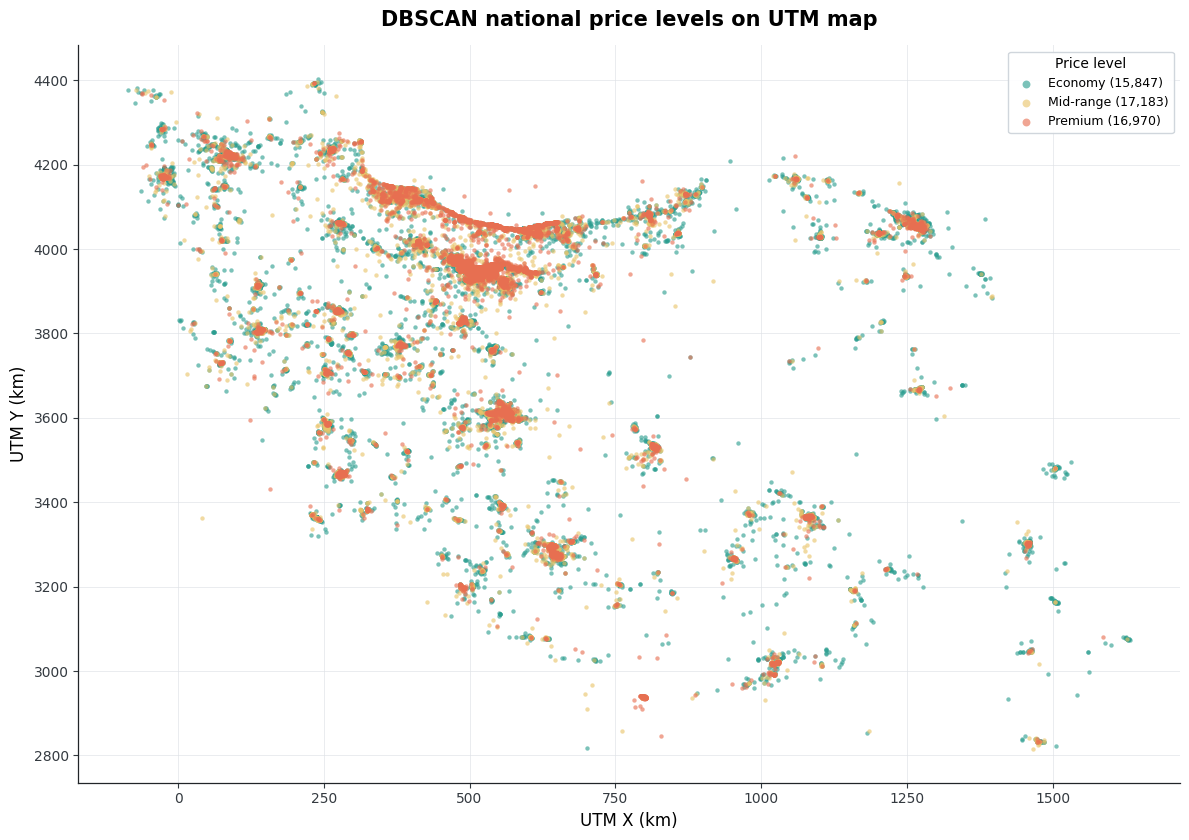

In [22]:
plot_index = price_stratified_sample_indices(
    data=data,
    target_size=min(PLOT_SAMPLE_SIZE, len(data)),
    random_state=RANDOM_STATE + 101,
    price_bins=100,
    density_power=0.85,
    min_per_bin=1
)

plot_price_level_map(
    data=data,
    label_col="dbscan_cluster_name",
    title="DBSCAN national price levels on UTM map",
    output_path=RESULT_DIR / "dbscan_price_levels_utm_map.png",
    sample_index=plot_index
)

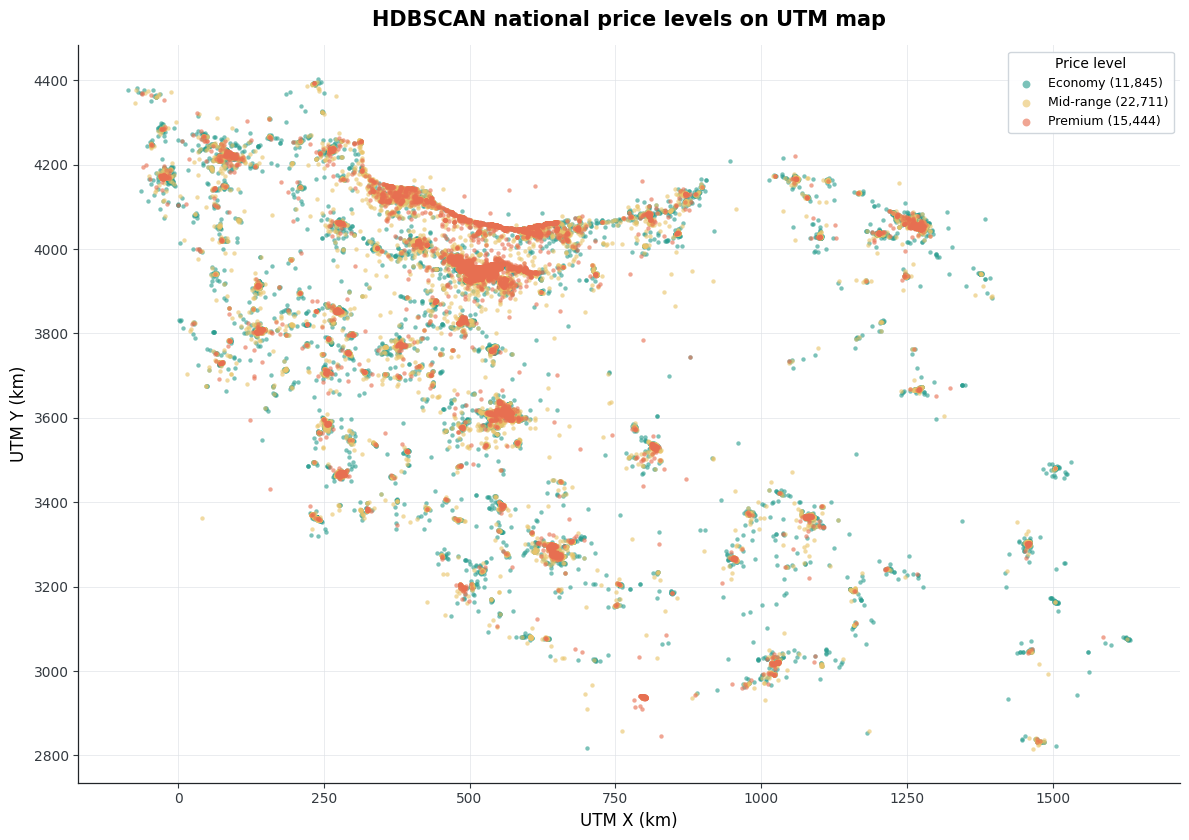

In [23]:
plot_price_level_map(
    data=data,
    label_col="hdbscan_cluster_name",
    title="HDBSCAN national price levels on UTM map",
    output_path=RESULT_DIR / "hdbscan_price_levels_utm_map.png",
    sample_index=plot_index
)

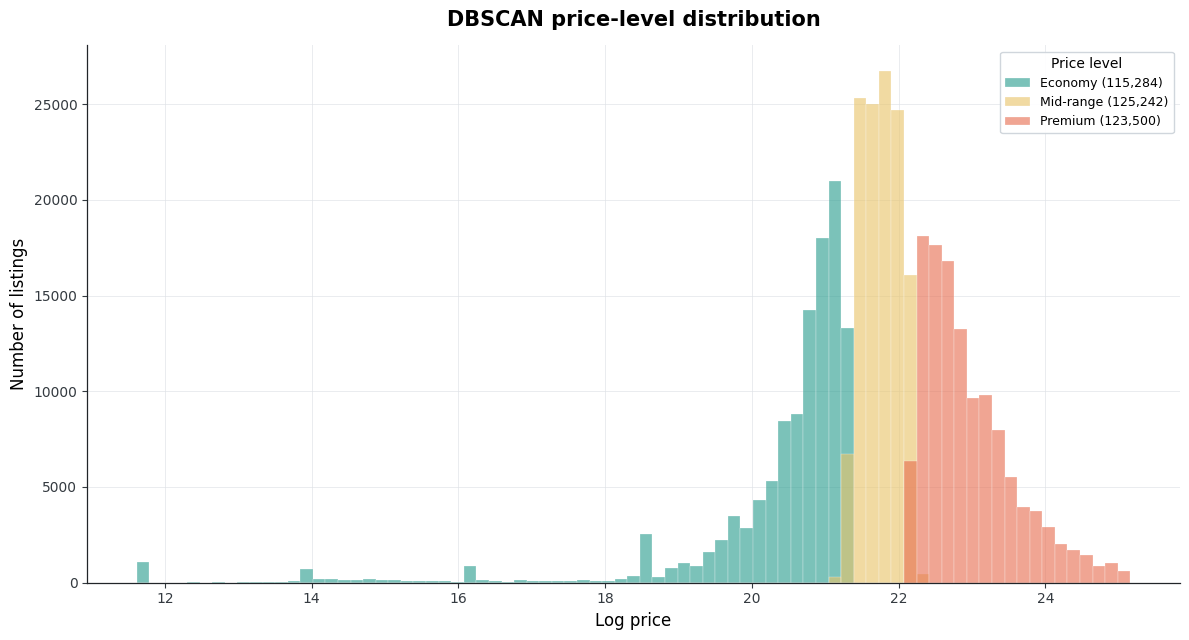

In [24]:
plot_price_distribution(
    data=data,
    label_col="dbscan_cluster_name",
    title="DBSCAN price-level distribution",
    output_path=RESULT_DIR / "dbscan_price_distribution.png"
)

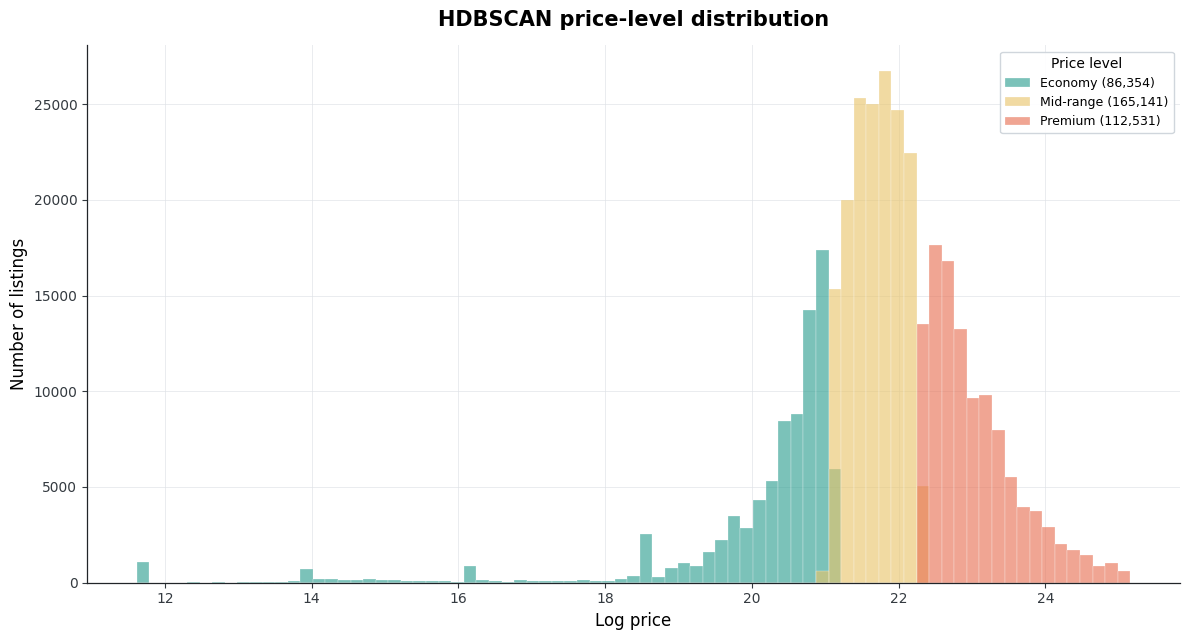

In [25]:
plot_price_distribution(
    data=data,
    label_col="hdbscan_cluster_name",
    title="HDBSCAN price-level distribution",
    output_path=RESULT_DIR / "hdbscan_price_distribution.png"
)

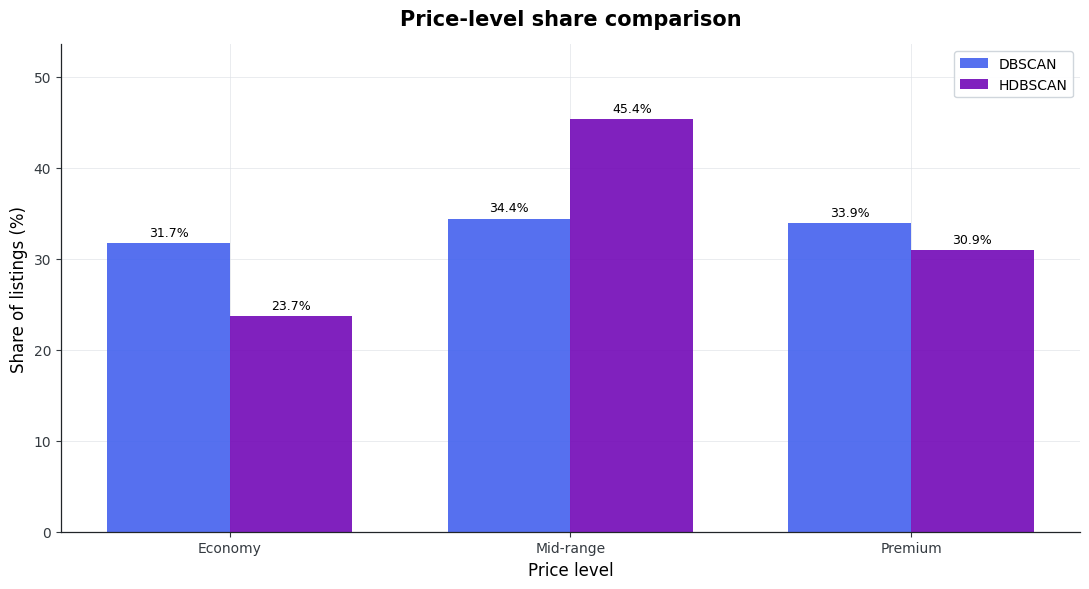

In [26]:
plot_price_level_counts(
    data=data,
    dbscan_col="dbscan_cluster_name",
    hdbscan_col="hdbscan_cluster_name",
    output_path=RESULT_DIR / "price_level_count_comparison.png"
)

In [27]:
data.to_csv(RESULT_DIR / "price_level_clustering_result.csv", index=False)

light_columns = [
    "latitude",
    "longitude",
    "price",
    "log_price",
    "utm_x",
    "utm_y",
    "dbscan_micro_cluster",
    "dbscan_cluster",
    "dbscan_cluster_name",
    "hdbscan_micro_cluster",
    "hdbscan_cluster",
    "hdbscan_cluster_name",
    "hdbscan_strength"
]

existing_light_columns = [col for col in light_columns if col in data.columns]

data[existing_light_columns].to_csv(
    RESULT_DIR / "price_level_clustering_result_light.csv",
    index=False
)

dbscan_summary.to_csv(RESULT_DIR / "dbscan_price_level_summary.csv")
hdbscan_summary.to_csv(RESULT_DIR / "hdbscan_price_level_summary.csv")

dbscan_results_df.to_csv(RESULT_DIR / "dbscan_hyperparameter_search.csv", index=False)
hdbscan_results_df.to_csv(RESULT_DIR / "hdbscan_hyperparameter_search.csv", index=False)

dbscan_attempts_df.to_csv(RESULT_DIR / "dbscan_final_attempts.csv", index=False)
hdbscan_attempts_df.to_csv(RESULT_DIR / "hdbscan_final_attempts.csv", index=False)

comparison_df.to_csv(RESULT_DIR / "dbscan_vs_hdbscan_price_level_comparison.csv", index=False)

best_params = {
    "data": {
        "data_path": DATA_PATH,
        "price_column": PRICE_COL,
        "rows_after_cleaning": int(len(data))
    },
    "dbscan": {
        "eps": dbscan_eps,
        "min_samples": dbscan_min_samples,
        "balance_strength": dbscan_balance_strength,
        "micro_metrics": dbscan_micro_metrics,
        "final_metrics": dbscan_final_metrics,
        "cluster_names": PRICE_LEVEL_NAMES
    },
    "hdbscan": {
        "min_samples": hdbscan_min_samples,
        "min_cluster_size": hdbscan_min_cluster_size,
        "cluster_selection_method": hdbscan_cluster_selection_method,
        "micro_metrics": hdbscan_micro_metrics,
        "final_metrics": hdbscan_final_metrics,
        "cluster_names": PRICE_LEVEL_NAMES
    }
}

save_json(RESULT_DIR / "best_price_level_clustering_params.json", best_params)

zip_path = shutil.make_archive(
    base_name=str(OUTPUT_ROOT / "price_level_clustering_outputs"),
    format="zip",
    root_dir=RESULT_DIR
)

zip_path

'/kaggle/working/price_level_clustering_outputs.zip'

In [28]:
print_final_report(
    dbscan_final_metrics,
    hdbscan_final_metrics
)

print("DBSCAN price-level summary:")
display(dbscan_summary[["ads_count", "share", "median_price_billion", "min_price_billion", "max_price_billion"]].round(4))

print("HDBSCAN price-level summary:")
display(hdbscan_summary[["ads_count", "share", "median_price_billion", "min_price_billion", "max_price_billion"]].round(4))


DBSCAN Price-Level Result
Clusters: 3
Noise Ratio: 0.0000
Silhouette: 0.3857
Davies-Bouldin: 0.7100
Calinski-Harabasz: 6181.10
Max Cluster Share: 0.3440
Min Cluster Share: 0.3167
Balance Gap: 0.0274

HDBSCAN Price-Level Result
Clusters: 3
Noise Ratio: 0.0000
Silhouette: 0.4336
Davies-Bouldin: 0.7007
Calinski-Harabasz: 7355.57
Max Cluster Share: 0.4537
Min Cluster Share: 0.2372
Balance Gap: 0.2164

DBSCAN price-level summary:


,,ads_count,share,median_price_billion,min_price_billion,max_price_billion
dbscan_cluster,dbscan_cluster_name,,,,,
0,Economy,115284,0.3167,1.1,0.0001,1.804
1,Mid-range,125242,0.3440,2.8,1.5250,4.932
2,Premium,123500,0.3393,8.0,4.3700,84.300


HDBSCAN price-level summary:


,,ads_count,share,median_price_billion,min_price_billion,max_price_billion
hdbscan_cluster,hdbscan_cluster_name,,,,,
0,Economy,86354,0.2372,0.890,0.0001,1.463
1,Mid-range,165141,0.4537,2.675,1.3550,5.129
2,Premium,112531,0.3091,8.500,4.6080,84.300


In [29]:
if dbscan_final_metrics["n_clusters"] != 3:
    raise ValueError("DBSCAN final result is not exactly 3 clusters.")

if hdbscan_final_metrics["n_clusters"] != 3:
    raise ValueError("HDBSCAN final result is not exactly 3 clusters.")

if data["dbscan_cluster_name"].isna().any():
    raise ValueError("DBSCAN has missing cluster names.")

if data["hdbscan_cluster_name"].isna().any():
    raise ValueError("HDBSCAN has missing cluster names.")

print("Final notebook completed successfully.")

Final notebook completed successfully.
